# 24 &middot; Subspace Mixed FEM (MFEM)

A soft beam, pinned at its left edge, falls under gravity. We simulate it two ways in the same small
**skinning-eigenmode subspace** $x = B\,u + q$: **subspace FEM** (Newton on inertia + elastic + pin +
gravity at every backward-Euler step) and **Subspace Mixed FEM** from
[Trusty et&nbsp;al.](https://www.dgp.toronto.edu/projects/subspace-mfem/), which adds a per-element
**stretch** variable $a$, tied to the deformation by a constraint, so that the elastic energy becomes
element-local:

$$\min_{u,\,a}\; E_\text{inertia}(u) + E_\text{elastic}(a) + E_\text{pin}(u) + E_\text{gravity}(u) \quad\text{s.t.}\quad S\big(F(u)\big) = a .$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import igl
import simkit
import utils

np.seterr(all="ignore")   # dense @ sparse emits spurious 'divide by zero in matmul' warnings; the products are exact

NOTEBOOK = "024_subspace_mixed_fem"                                # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK) # results/024_subspace_mixed_fem/
MEDIA_DIR = "media"                                                # tracked copies for the website
# mesh
NX, NY = 40, 8                      # grid resolution (vertices along x, y)
WIDTH, HEIGHT = 3.0, 0.5            # beam size
# material and loads
MATERIAL = "macklin-mueller-neo-hookean"   # has a stretch (S) form in simkit, which MFEM needs
YM, PR = 1e5, 0.45                  # Young's modulus, Poisson ratio
RHO = 1e3                           # density
GRAVITY = -9.81                     # vertical gravitational acceleration
K_PIN = 1e8                         # soft-pin stiffness on the left edge
# subspace and cubature
N_MODES = 10                        # skinning eigenmodes (subspace dimension 6 * N_MODES in 2D)
N_CUBATURE = 400                    # spectral cubature points (one triangle per cluster)
# the drop
DT = 0.05                           # timestep
N_STEPS = 120                       # number of steps
MAX_ITER = 30                       # max solver iterations per step (both methods)
TOL = 1e-6                          # solver tolerance (Newton: step length, SQP: decrement)
RHO_AUG = 0.0                       # augmented-Lagrangian weight of the drop (0 = plain Lagrangian)
SNAPSHOT_STEPS = [0, 12, 21, 41, 119]   # steps drawn as still frames (start, falling, lowest, rebound, end)
FRAME_STRIDE, FPS = 2, 24           # video: every FRAME_STRIDE-th step, frames per second
# finite-difference check of the MFEM blocks
FD_STEP = 1e-6                      # central-difference step
FD_NOISE = 0.05                     # size of the random state perturbation
FD_PASS = 1e-4                      # relative error below which a block counts as correct
FD_RHO_AUG = [0.0, 50.0]            # augmentation weights whose blocks are checked
SPD_RHO_AUG = [0.0, 50.0, 1e4]      # augmentation weights whose H_u is checked for positive definiteness
SEED = 0                            # random seed of the perturbation
# regularization study: one hard step from rest, swept over rho_aug
H_HARD = [0.5, 1.0]                 # its timesteps (a larger step is harder)
RHO_SWEEP = [0.0, 1.0, 10.0, 100.0, 1e3, 1e4, 1e5, 1e6]
MAX_ITER_HARD = 60                  # iteration cap (reaching it = stalled)
# stiffness study: one very large step from rest, swept over Young's modulus
H_SWEEP = 10.0                      # its timestep (close to a static solve)
YM_SWEEP = [1e4, 1e5, 1e6, 1e7, 1e8, 1e9]
MAX_ITER_SWEEP = 40                 # iteration cap of both solvers
TIMING_REPS = 5                     # repetitions of the per-iteration timing (best one counts)

## The beam

A $3 \times 0.5$ grid from libigl; its left edge (blue squares) is held by a stiff penalty spring, and the
orange dot is the tip vertex whose height we track.

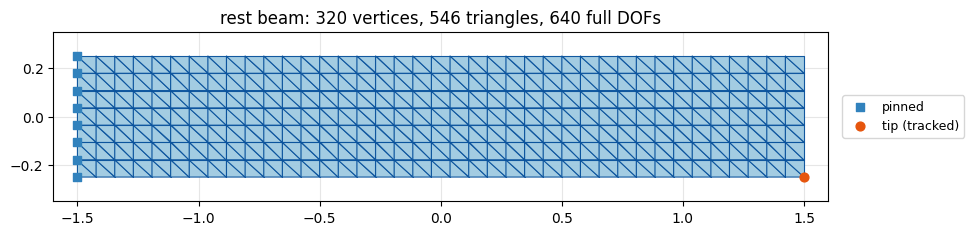

In [2]:
V_grid, T = igl.triangulated_grid(NX, NY)                 # unit square, NX x NY vertices
X = (V_grid - 0.5) * np.array([WIDTH, HEIGHT])           # centered WIDTH x HEIGHT beam
n, dim = X.shape
q = X.reshape(-1, 1)                                     # rest positions: x = B u + q
pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
tip = int(np.argmax(X[:, 0]))

fig, ax = plt.subplots(figsize=(10, 2.3))
utils.plot_mesh(ax, X, T, pins=pin_idx, title=f"rest beam: {n} vertices, {len(T)} triangles, {n * dim} full DOFs")
ax.scatter(*X[tip], s=40, color=utils.HANDLE_C, zorder=6, label="tip (tracked)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "024_mesh.png"))
plt.show()

## The subspace: skinning eigenmodes

`simkit.skinning_eigenmodes` returns `N_MODES` smooth weight fields $w_k$ (Laplacian eigenvectors) and the
linear-blend-skinning basis $B$: every weight carries its own 2D affine transform (6 DOFs), so
$x = B\,u + q$ has only $6 \cdot$ `N_MODES` unknowns $u$, and $u = 0$ is the rest pose. $B$ is **dense**:
every mode moves every vertex. Below, each weight is scaled to $[-1, 1]$: $w_0$ is constant (it carries the
global affine motion), and the others oscillate ever faster along the beam, then across it.

B: 640 x 60 dense basis (10 weights x 6 affine DOFs)


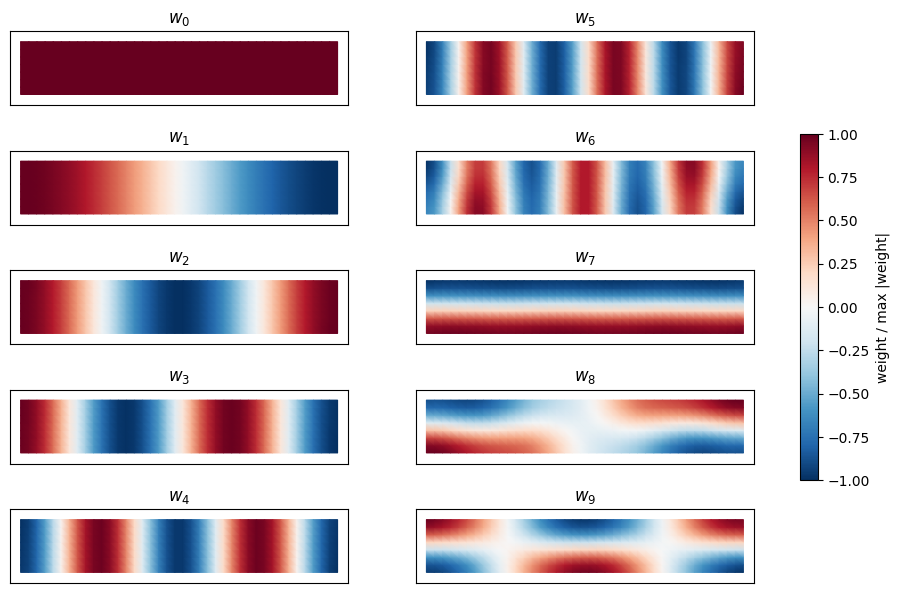

In [3]:
W, eigvals, B = simkit.skinning_eigenmodes(X, T, N_MODES, mu=np.full((len(T), 1), YM))
n_u = B.shape[1]
print(f"B: {B.shape[0]} x {n_u} dense basis ({N_MODES} weights x 6 affine DOFs)")

fig, axes = plt.subplots(N_MODES // 2, 2, figsize=(12, 0.75 * N_MODES))
for k, ax in enumerate(axes.T.flat):
    m = utils.plot_scalar_field(ax, X, T, W[:, k] / np.abs(W[:, k]).max(), title=f"$w_{{{k}}}$",
                                cmap="RdBu_r", vmin=-1, vmax=1, edges=False, colorbar=False)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(m, ax=axes, shrink=0.6, label="weight / max |weight|")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "skinning_weights.png"),
                              copy_to=os.path.join(MEDIA_DIR, "024_skinning_weights.png"))
plt.show()

## Cubature

Both methods evaluate the elastic energy only at a subset of triangles. `simkit.spectral_cubature`
clusters the triangles by their (averaged) skinning weights into `N_CUBATURE` clusters, keeps one
representative triangle per cluster, and weights it by the cluster's total area. Top: the cluster of every
triangle; bottom: the weight of the selected triangles (the others are blank). On this small mesh 400 of
the 546 triangles survive and no cluster holds more than 3, so the saving is modest; what matters is that
the elastic cost now depends on `N_CUBATURE`, not on the mesh resolution.

400 cubature triangles out of 546; 259 clusters hold one triangle, the largest holds 3


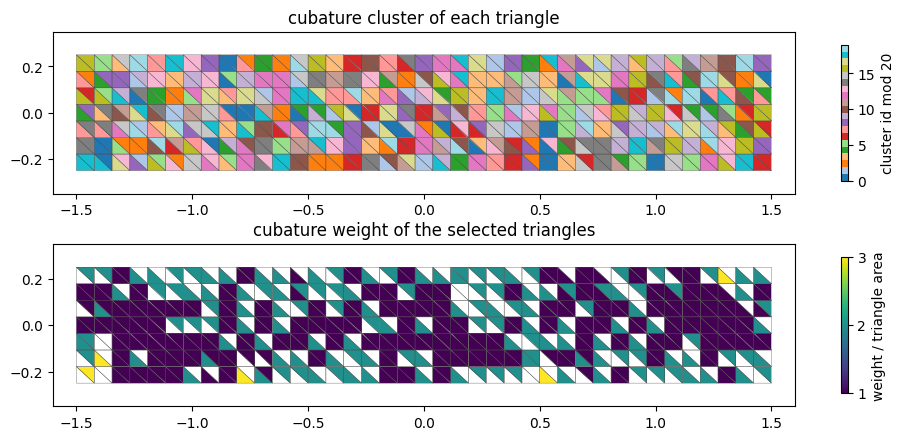

In [4]:
cub_idx, cub_w, cub_labels = simkit.spectral_cubature(X, T, W, N_CUBATURE, return_labels=True)
cluster_size = np.bincount(cub_labels, minlength=N_CUBATURE)
print(f"{N_CUBATURE} cubature triangles out of {len(T)}; "
      f"{np.sum(cluster_size == 1)} clusters hold one triangle, the largest holds {cluster_size.max()}")

tri_area = simkit.volume(X, T).ravel()
cub_field = np.full(len(T), np.nan)
cub_field[cub_idx] = cub_w / tri_area[cub_idx]
fig, axes = plt.subplots(2, 1, figsize=(10, 4.4))
utils.plot_scalar_field(axes[0], X, T, cub_labels % 20, title="cubature cluster of each triangle",
                        cmap="tab20", label="cluster id mod 20")
utils.plot_scalar_field(axes[1], X, T, cub_field, title="cubature weight of the selected triangles",
                        cmap="viridis", vmin=1, vmax=np.nanmax(cub_field), label="weight / triangle area")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "cubature.png"),
                              copy_to=os.path.join(MEDIA_DIR, "024_cubature.png"))
plt.show()

## Shared operators

Built once from simkit and used by both methods: Lamé parameters and quadrature weights `vol` at the
cubature triangles, the reduced mass matrix $M_B = B^\top M B$, the deformation gradients at the
cubature triangles $F = G J B\,u + G J q$ (`GJB`, `GJq`, with $G$ selecting those triangles), and the
pin and gravity terms rewritten in $u$. The pin penalizes absolute positions $x = B u + q$; substituting
leaves a linear term $B^\top(Q_\text{pin}\,q + b_\text{pin})$ that anchors the pin at the rest offset $q$.
Left: the lumped vertex mass (lighter on the boundary); right: the reduced mass matrix $M_B$, dense like $B$.

GJB: 1600 x 60 (4 entries of F per cubature triangle), 8 pinned vertices


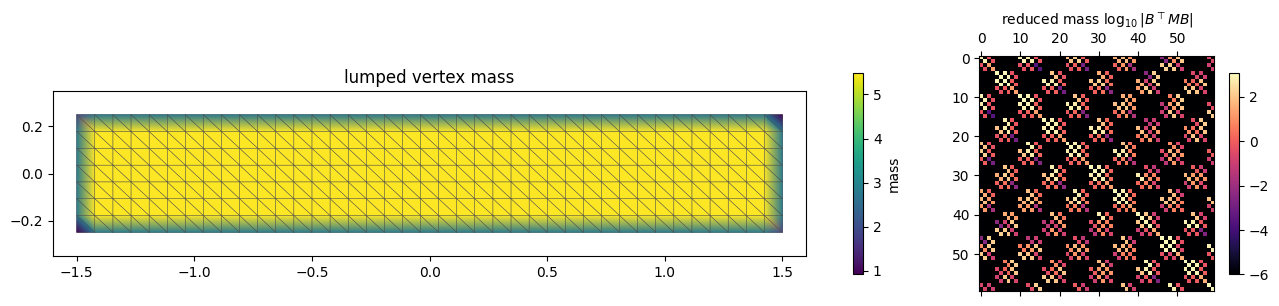

In [5]:
mu_value, lam_value = simkit.ympr_to_lame(YM, PR)
mu = np.full((N_CUBATURE, 1), mu_value)
lam = np.full((N_CUBATURE, 1), lam_value)
vol = cub_w.reshape(-1, 1)                                   # cubature weights (cluster areas)

M = sp.sparse.kron(simkit.massmatrix(X, T, rho=RHO), sp.sparse.identity(dim))
M_B = B.T @ M @ B                                            # reduced mass matrix

G = sp.sparse.kron(simkit.selection_matrix(cub_idx, len(T)), sp.sparse.identity(dim * dim))
J = simkit.deformation_jacobian(X, T)
fem_precomp = simkit.energies.ElasticEnergyZPrecomp(B, q, G, J, dim)   # holds GJB = G J B, GJq = G J q
GJB, GJq = fem_precomp.JB, fem_precomp.Jx0

Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)
Q_pin_B = B.T @ Q_pin @ B                                    # reduced pin quadratic
b_pin_B = B.T @ (Q_pin @ q + b_pin)                          # reduced pin linear term (anchored at q)
f_g_B = B.T @ simkit.gravity_force(X, T, a=GRAVITY, rho=RHO).reshape(-1, 1)   # reduced gravity force
print(f"GJB: {GJB.shape[0]} x {GJB.shape[1]} (4 entries of F per cubature triangle), "
      f"{len(pin_idx)} pinned vertices")

fig, axes = plt.subplots(1, 2, figsize=(13, 3), gridspec_kw={"width_ratios": [3.2, 1]})
utils.plot_scalar_field(axes[0], X, T, simkit.massmatrix(X, T, rho=RHO).diagonal(), title="lumped vertex mass",
                        cmap="viridis", label="mass")
im = axes[1].matshow(np.log10(np.abs(M_B) + 1e-12), cmap="magma", vmin=-6)
axes[1].set_title(r"reduced mass $\log_{10}|B^\top M B|$", fontsize=10)
fig.colorbar(im, ax=axes[1], shrink=0.8)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mass.png"),
                              copy_to=os.path.join(MEDIA_DIR, "024_mass.png"))
plt.show()

## Subspace FEM: `fem_system`

The classic recipe: the elastic energy is a function of the deformation gradients $F(u)$, evaluated at
the cubature triangles (`simkit.energies.elastic_*_z`). Its subspace Hessian
$(GJB)^\top H_F\,(GJB)$ is dense because $B$ is: every element couples all subspace DOFs. The system is
rebuilt at every step with that step's history $u_n, u_{n-1}$.

In [6]:
def fem_system(u_curr, u_prev, h, mu, lam):
    """Backward-Euler step of subspace FEM: inertia + elastic + pin + gravity, in reduced coordinates u."""

    def energy_func(u):
        E_inertia = simkit.energies.kinetic_energy_be(u, u_curr, u_prev, M_B, h)
        E_elastic = simkit.energies.elastic_energy_z(u, mu, lam, vol, MATERIAL, fem_precomp)
        E_pin = simkit.energies.quadratic_energy(u, Q_pin_B, b_pin_B)
        E_gravity = -(f_g_B.T @ u).item()
        E_total = E_inertia + E_elastic + E_pin + E_gravity
        return E_total

    def gradient_func(u):
        g_inertia = simkit.energies.kinetic_gradient_be(u, u_curr, u_prev, M_B, h)
        g_elastic = simkit.energies.elastic_gradient_z(u, mu, lam, vol, MATERIAL, fem_precomp)
        g_pin = simkit.energies.quadratic_gradient(u, Q_pin_B, b_pin_B)
        g_gravity = -f_g_B
        g_total = g_inertia + g_elastic + g_pin + g_gravity
        return g_total

    def hessian_func(u):
        H_inertia = simkit.energies.kinetic_hessian_be(M_B, h)
        H_elastic = simkit.energies.elastic_hessian_z(u, mu, lam, vol, MATERIAL, fem_precomp)
        H_pin = simkit.energies.quadratic_hessian(Q_pin_B)
        H_total = H_inertia + H_elastic + H_pin
        return H_total

    return energy_func, gradient_func, hessian_func

## Mixed FEM: the stretch constraint

The polar decomposition $F = R\,S$ splits off the symmetric stretch $S$, which is all an isotropic
elastic energy depends on. MFEM gives every cubature triangle an auxiliary stretch
$a = (s_{xx}, s_{yy}, s_{xy})$ and the constraint $c(u, a) = S(F(u)) - a = 0$. `Ci` (from
`simkit.symmetric_stretch_map`) extracts those 3 components from the 4 entries of $S$, and the metric
$W = \mathrm{diag}(w)$ weights them by the cubature area, counting $s_{xy}$ twice because it appears twice in $S$.
`stretch_residual` evaluates $c$ and `stretch_jacobian` its derivative $\partial S/\partial u$. The printout
counts the mixed unknowns: the 60 positions, plus stretch and multiplier components that the solver eliminates.

In [7]:
_, Ci = simkit.symmetric_stretch_map(N_CUBATURE, dim)
n_sym = dim * (dim + 1) // 2                                 # independent stretch components (3 in 2D)
n_a = Ci.shape[0]                                            # stretch DOFs
w = np.kron(vol, np.array([[1.0], [1.0], [2.0]]))            # constraint metric weights (s_xx, s_yy, s_xy)
W_c = sp.sparse.diags(w.ravel())
a_rest = np.tile([[1.0], [1.0], [0.0]], (N_CUBATURE, 1))     # identity stretch
u_rest = np.zeros((n_u, 1))                                  # rest pose
ll_rest = np.zeros((n_a, 1))                                 # zero multipliers

def stretch_residual(u, a):
    """Constraint c = S(F(u)) - a, three components per cubature triangle."""
    F = (GJB @ u + GJq).reshape(-1, dim, dim)
    c = Ci @ simkit.stretch(F) - a
    return c

def stretch_jacobian(u):
    """dS/du^T, shape (n_u, n_a): the derivative of one polar decomposition per cubature triangle."""
    dSdu = simkit.stretch_gradient_dz(u, GJB, Ci=Ci, dim=dim, GJq=GJq)
    return dSdu

print(f"state p = [u; a; lambda]: {n_u} + {n_a} + {n_a} = {n_u + 2 * n_a} unknowns")

state p = [u; a; lambda]: 60 + 1200 + 1200 = 2460 unknowns


## `mfem_system`

The unknowns are $p = [u;\,a;\,\lambda]$, with Lagrange multipliers $\lambda$ for the constraint, and
`simkit.solvers.sqp_mfem` minimizes the augmented-Lagrangian merit below. It takes gradient blocks
`[f_u, f_a, f_lambda]` (the gradient without the multiplier coupling, which it adds itself, and the residual
$Wc$) and Hessian blocks `[H_u, H_a, G_u, G_a, G_a_inv]` (its docstring calls the stretch block $z$). The
elastic Hessian $H_a$ is **block-diagonal** (3&times;3 per triangle); the positions only see inertia, pin and
the constraint Jacobian $G_u = \tfrac{\partial S}{\partial u}^{\!\top} W$, and $H_u$ drops the curvature of
$S$ (Gauss-Newton). Since $G_a = -W$ is diagonal, the solver eliminates $a$ and $\lambda$ and solves one
$n_u \times n_u$ system per iteration. The penalty gradient in $u$ is
$\rho_\text{aug}\tfrac{\partial S}{\partial u}^{\!\top} W c$, weighted by $W$ once, like the penalty itself.
`solve_mfem` runs the solver and counts its iterations.

$$E(p) = \psi(a) + E_\text{inertia}(u) + E_\text{pin}(u) + E_\text{gravity}(u) + \lambda^\top W c + \tfrac12\,\rho_\text{aug}\, c^\top W c$$

In [8]:
def mfem_system(u_curr, u_prev, h, mu, lam, rho_aug):
    """Backward-Euler step of subspace mixed FEM on the stacked state p = [u; a; lambda]."""

    def split(p):
        return p[:n_u], p[n_u:n_u + n_a], p[n_u + n_a:]

    def energy_func(p):
        u, a, ll = split(p)
        c = stretch_residual(u, a)
        E_elastic = simkit.energies.elastic_energy_S(a.reshape(-1, n_sym), mu, lam, vol, MATERIAL)
        E_inertia = simkit.energies.kinetic_energy_be(u, u_curr, u_prev, M_B, h)
        E_pin = simkit.energies.quadratic_energy(u, Q_pin_B, b_pin_B)
        E_gravity = -(f_g_B.T @ u).item()
        E_lagrange = (ll.T @ (w * c)).item()
        E_augment = 0.5 * rho_aug * (c.T @ (w * c)).item()
        E_total = E_elastic + E_inertia + E_pin + E_gravity + E_lagrange + E_augment
        return E_total

    def gradient_func(p):
        u, a, ll = split(p)
        wc = w * stretch_residual(u, a)
        f_u_inertia = simkit.energies.kinetic_gradient_be(u, u_curr, u_prev, M_B, h)
        f_u_pin = simkit.energies.quadratic_gradient(u, Q_pin_B, b_pin_B)
        f_u_gravity = -f_g_B
        f_u_augment = rho_aug * (stretch_jacobian(u) @ wc) if rho_aug else 0.0   # skip the Jacobian when unused
        f_u = f_u_inertia + f_u_pin + f_u_gravity + f_u_augment
        f_a_elastic = simkit.energies.elastic_gradient_S(a.reshape(-1, n_sym), mu, lam, vol, MATERIAL).reshape(-1, 1)
        f_a_augment = -rho_aug * wc                                          # dc/da = -I
        f_a = f_a_elastic + f_a_augment
        f_ll = wc
        g_blocks = [f_u, f_a, f_ll]
        return g_blocks

    def hessian_func(p):
        u, a, ll = split(p)
        dSdu = stretch_jacobian(u)
        H_u_inertia = simkit.energies.kinetic_hessian_be(M_B, h)
        H_u_pin = simkit.energies.quadratic_hessian(Q_pin_B)
        H_u_augment = rho_aug * (dSdu @ W_c @ dSdu.T)                       # Gauss-Newton
        H_u = H_u_inertia + H_u_pin + H_u_augment
        H_a_elastic = sp.sparse.block_diag(list(simkit.energies.elastic_hessian_S(a.reshape(-1, n_sym), mu, lam, vol, MATERIAL)))
        H_a_augment = rho_aug * W_c
        H_a = H_a_elastic + H_a_augment
        G_u = dSdu @ W_c
        G_a = -W_c
        G_a_inv = sp.sparse.diags(1.0 / G_a.diagonal())
        h_blocks = [H_u, H_a, G_u, G_a, G_a_inv]
        return h_blocks

    return energy_func, gradient_func, hessian_func


def solve_mfem(p0, energy_func, gradient_func, hessian_func, max_iter):
    """Run sqp_mfem and also return its iteration count (it calls hessian_func once per iteration)."""
    calls = [0]

    def counted_hessian(p):
        calls[0] += 1
        return hessian_func(p)

    p = simkit.solvers.sqp_mfem(p0, energy_func, counted_hessian, gradient_func,
                                tolerance=TOL, max_iter=max_iter, do_line_search=True)
    return p, calls[0]

### Checking the blocks by finite differences

At a random state we compare against central differences (`simkit.gradient_cfd`) of the merit $E(p)$: the
gradient blocks plus the multiplier coupling the solver adds ($G_u\lambda$, $G_a\lambda$) must equal
$\nabla E$, $H_a$ must equal $\partial f_a/\partial a$, and the Gauss-Newton $H_u$ is exact only at
$\lambda = 0,\ \rho_\text{aug} = 0$; it must also stay positive definite for every $\rho_\text{aug} \ge 0$,
which the condensed solve needs. All errors land near $10^{-11}$, far below `FD_PASS`, and $H_u$ is positive
definite for every tested weight (smallest eigenvalue about $2\cdot10^{-3}$ against $2\cdot10^{10}$ for the
largest: the stiff pin makes it badly conditioned, not indefinite).

gradient, rho_aug=0        relative error 6.1e-11
H_a, rho_aug=0             relative error 7.1e-11
gradient, rho_aug=50       relative error 6.7e-11
H_a, rho_aug=50            relative error 7.1e-11
H_u, lambda=0, rho_aug=0   relative error 1.2e-11
H_u at rho_aug =       0: min eigenvalue 2.18e-03 (max 2.26e+10)
H_u at rho_aug =      50: min eigenvalue 2.23e-03 (max 2.26e+10)
H_u at rho_aug =   10000: min eigenvalue 6.57e-03 (max 2.26e+10)


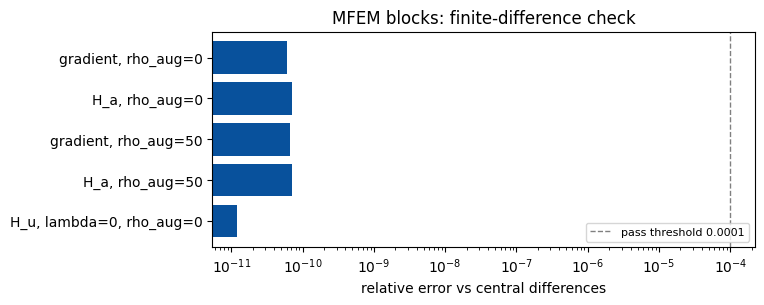

In [9]:
rng = np.random.default_rng(SEED)
u_t = FD_NOISE * rng.standard_normal((n_u, 1))
a_t = a_rest + FD_NOISE * rng.standard_normal((n_a, 1))
ll_t = FD_NOISE * rng.standard_normal((n_a, 1))
p_t = np.vstack([u_t, a_t, ll_t])

def relative_error(approx, exact):
    return np.linalg.norm(approx - exact) / np.linalg.norm(exact)

fd_errors = {}
for rho_aug in FD_RHO_AUG:
    energy_func, gradient_func, hessian_func = mfem_system(u_rest, u_rest, DT, mu, lam, rho_aug)
    f_u, f_a, f_ll = gradient_func(p_t)
    H_u, H_a, G_u, G_a, G_a_inv = hessian_func(p_t)
    grad_u = f_u + G_u @ ll_t                                # + the multiplier coupling sqp_mfem adds
    grad_a = f_a + G_a @ ll_t
    g_blocks = np.vstack([grad_u, grad_a, f_ll])
    g_fd = simkit.gradient_cfd(lambda y: np.array([energy_func(y.reshape(-1, 1))]), p_t.ravel(), FD_STEP).reshape(-1, 1)
    H_a_fd = simkit.gradient_cfd(lambda y: gradient_func(np.vstack([u_t, y.reshape(-1, 1), ll_t]))[1].ravel(),
                                 a_t.ravel(), FD_STEP)
    fd_errors[f"gradient, rho_aug={rho_aug:g}"] = relative_error(g_blocks, g_fd)
    fd_errors[f"H_a, rho_aug={rho_aug:g}"] = relative_error(H_a.toarray(), H_a_fd)

p_t0 = np.vstack([u_t, a_t, ll_rest])                        # lambda = 0
energy_func, gradient_func, hessian_func = mfem_system(u_rest, u_rest, DT, mu, lam, 0.0)
H_u_fd = simkit.gradient_cfd(lambda y: gradient_func(np.vstack([y.reshape(-1, 1), a_t, ll_rest]))[0].ravel(),
                             u_t.ravel(), FD_STEP)
fd_errors["H_u, lambda=0, rho_aug=0"] = relative_error(np.asarray(hessian_func(p_t0)[0]), H_u_fd)
for name, err in fd_errors.items():
    print(f"{name:26s} relative error {err:.1e}")

for rho_aug in SPD_RHO_AUG:
    H_u = np.asarray(mfem_system(u_rest, u_rest, DT, mu, lam, rho_aug)[2](p_t)[0])
    eig = np.linalg.eigvalsh(0.5 * (H_u + H_u.T))
    print(f"H_u at rho_aug = {rho_aug:7g}: min eigenvalue {eig.min():.2e} (max {eig.max():.2e})")

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(range(len(fd_errors)), list(fd_errors.values()), color=utils.MESH_EDGE)
ax.axvline(FD_PASS, color="0.5", ls="--", lw=1, label=f"pass threshold {FD_PASS:g}")
ax.set_yticks(range(len(fd_errors)), list(fd_errors.keys()))
ax.set_xscale("log"); ax.invert_yaxis()
ax.set_xlabel("relative error vs central differences")
ax.set_title("MFEM blocks: finite-difference check")
ax.legend(fontsize=8, loc="lower right")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "fd_check.png"),
                              copy_to=os.path.join(MEDIA_DIR, "024_fd_check.png"))
plt.show()

## Dropping the beam with both methods

Each backward-Euler step rebuilds the step's system from the history $(u_n, u_{n-1})$ and solves it:
Newton (`simkit.solvers.newton_solver`, started at $u_n + h\,v_n$) for FEM, and `sqp_mfem` warm-started
with the previous stretch and multipliers for MFEM. We record the full-space vertices $x = B u + q$, the
iterations per step, and MFEM's largest constraint violation $\max|c|$. Both runs reach the same lowest tip
height and end in the same pose, and their vertices never differ by more than $2\cdot10^{-4}$; MFEM needs
about twice as many iterations per step.

In [10]:
runs = {}
for method in ["FEM", "MFEM"]:
    u_curr, u_prev = u_rest.copy(), u_rest.copy()
    a, ll = a_rest.copy(), ll_rest.copy()
    frames, iters, residuals, stretches, multipliers = [], [], [], [], []
    for step in range(N_STEPS):
        if method == "FEM":
            energy_func, gradient_func, hessian_func = fem_system(u_curr, u_prev, DT, mu, lam)
            u_next, info = simkit.solvers.newton_solver(2 * u_curr - u_prev, energy_func, gradient_func, hessian_func,
                                                        tolerance=TOL, max_iter=MAX_ITER, do_line_search=True,
                                                        return_info=True)
            iters.append(info["iters"] + 1)
        else:
            energy_func, gradient_func, hessian_func = mfem_system(u_curr, u_prev, DT, mu, lam, RHO_AUG)
            p, n_iter = solve_mfem(np.vstack([u_curr, a, ll]), energy_func, gradient_func, hessian_func, MAX_ITER)
            u_next, a, ll = p[:n_u], p[n_u:n_u + n_a], p[n_u + n_a:]
            iters.append(n_iter)
            residuals.append(np.abs(stretch_residual(u_next, a)).max())
            stretches.append(a.reshape(-1, n_sym))
            multipliers.append(ll.reshape(-1, n_sym))
        u_prev, u_curr = u_curr, u_next.copy()
        frames.append((B @ u_curr + q).reshape(n, dim))
    runs[method] = {"frames": frames, "iters": np.array(iters), "residual": np.array(residuals),
                    "a": stretches, "ll": multipliers}

times = DT * np.arange(1, N_STEPS + 1)
gap = np.array([np.linalg.norm(xf - xm, axis=1).max() for xf, xm in zip(runs["FEM"]["frames"], runs["MFEM"]["frames"])])
for method, r in runs.items():
    tip_y = [x[tip, 1] for x in r["frames"]]
    print(f"{method:4s}: tip height {min(tip_y):+.3f} (lowest) -> {tip_y[-1]:+.3f} (last);  "
          f"iterations per step: mean {r['iters'].mean():.1f}, max {r['iters'].max()}")
print(f"MFEM reached the {MAX_ITER}-iteration cap on {np.sum(runs['MFEM']['iters'] >= MAX_ITER)} of {N_STEPS} steps")
print(f"largest FEM-MFEM vertex distance over the run: {gap.max():.1e}")

FEM : tip height -4.101 (lowest) -> -3.468 (last);  iterations per step: mean 7.7, max 13
MFEM: tip height -4.101 (lowest) -> -3.468 (last);  iterations per step: mean 15.8, max 30
MFEM reached the 30-iteration cap on 33 of 120 steps
largest FEM-MFEM vertex distance over the run: 2.1e-04


Validation plots of the run. The tip heights coincide (top left) and the methods stay within $2\cdot10^{-4}$
of each other (top right). On many steps MFEM's SQP creeps up to the cap (bottom left): it converges only
linearly there, because the Gauss-Newton $H_u$ ignores the $\lambda$-weighted curvature of $S$, which matters
when the stresses $\lambda$ are large. The constraint stays satisfied to $2\cdot10^{-6}$ or better (bottom right).

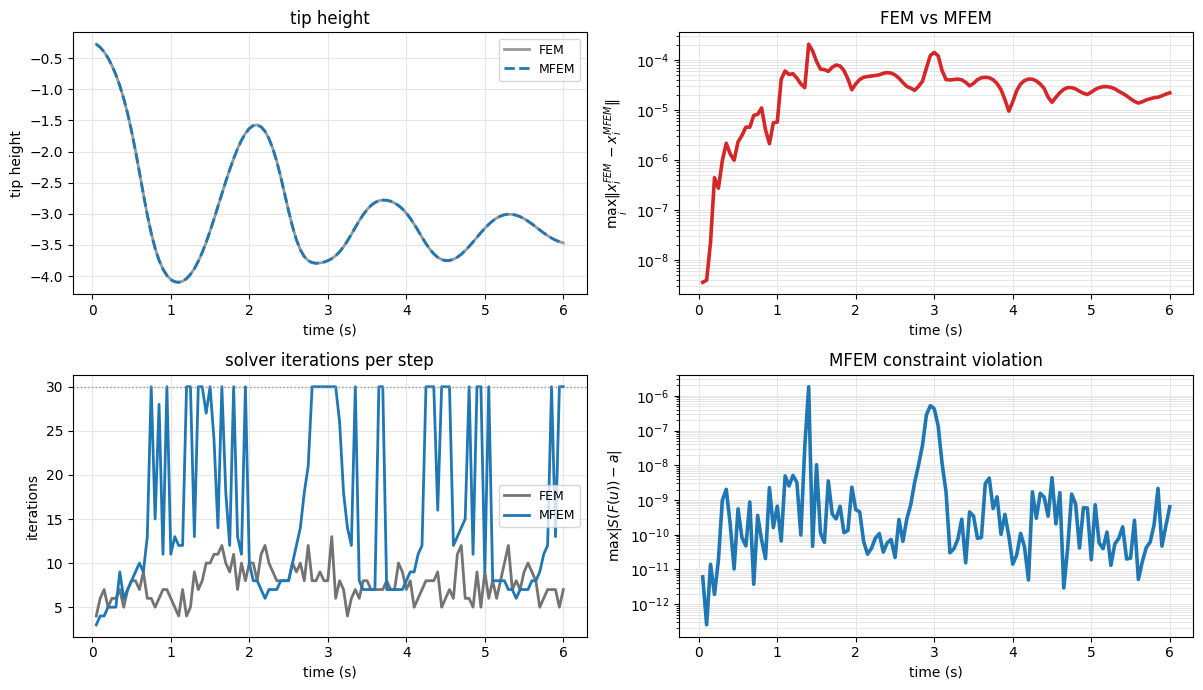

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
utils.line_plot(times, {"FEM": [x[tip, 1] for x in runs["FEM"]["frames"]],
                        "MFEM": [x[tip, 1] for x in runs["MFEM"]["frames"]]},
                xlabel="time (s)", ylabel="tip height", title="tip height",
                colors={"FEM": "0.6", "MFEM": "C0"}, ax=axes[0, 0])
axes[0, 0].lines[1].set_linestyle("--")
axes[0, 0].legend(fontsize=9)
utils.residual_plot({"max vertex distance": gap}, times, ax=axes[0, 1], colors={"max vertex distance": "C3"},
                    xlabel="time (s)", ylabel=r"$\max_i \|x_i^{FEM} - x_i^{MFEM}\|$", title="FEM vs MFEM")
utils.line_plot(times, {"FEM": runs["FEM"]["iters"], "MFEM": runs["MFEM"]["iters"]},
                xlabel="time (s)", ylabel="iterations", title="solver iterations per step",
                colors={"FEM": "0.45", "MFEM": "C0"}, ax=axes[1, 0])
axes[1, 0].axhline(MAX_ITER, color="0.6", ls=":", lw=1)
utils.residual_plot({"MFEM": runs["MFEM"]["residual"]}, times, ax=axes[1, 1], colors={"MFEM": "C0"},
                    xlabel="time (s)", ylabel=r"$\max |S(F(u)) - a|$", title="MFEM constraint violation")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "drop_validation.png"),
                              copy_to=os.path.join(MEDIA_DIR, "024_drop_validation.png"))
plt.show()

## Snapshots

FEM (thick gray) and MFEM (thin blue) at the start, while falling, at the lowest point, at the top of the
rebound and at the end. The blue edges sit exactly on the gray ones.

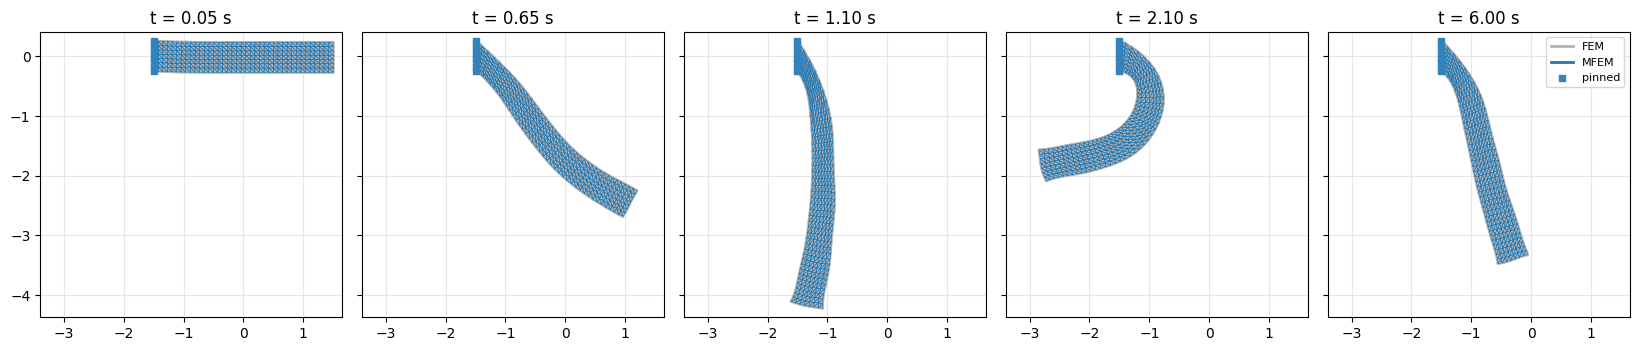

In [12]:
lims = utils.auto_limits(runs["FEM"]["frames"] + runs["MFEM"]["frames"], pad=0.15)
fig, axes = plt.subplots(1, len(SNAPSHOT_STEPS), figsize=(3.3 * len(SNAPSHOT_STEPS), 4.6), sharey=True)
for ax, s in zip(axes, SNAPSHOT_STEPS):
    utils.plot_mesh_overlay(ax, {"FEM": runs["FEM"]["frames"][s], "MFEM": runs["MFEM"]["frames"][s]}, T,
                            colors={"FEM": "0.7", "MFEM": "C0"}, lws={"FEM": 2.0, "MFEM": 0.4},
                            pin_pts=X[pin_idx], lims=lims, title=f"t = {times[s]:.2f} s", legend=(ax is axes[-1]))
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "frames.png"),
                              copy_to=os.path.join(MEDIA_DIR, "024_frames.png"))
plt.show()

## Animation

The whole drop, FEM in thick gray under MFEM in thin blue: the beam falls, swings past vertical, rebounds
and settles into an oscillation that backward Euler slowly damps.

In [13]:
steps = list(range(0, N_STEPS, FRAME_STRIDE))
fig, anim = utils.animate_mesh_overlay({"FEM": [runs["FEM"]["frames"][s] for s in steps],
                                        "MFEM": [runs["MFEM"]["frames"][s] for s in steps]}, T,
                                       colors={"FEM": "0.7", "MFEM": "C0"}, lws={"FEM": 2.0, "MFEM": 0.4},
                                       pin_pts=X[pin_idx], lims=lims, fps=FPS, figsize=(6, 5.5),
                                       titles=[f"drop under gravity, t = {times[s]:.2f} s" for s in steps])
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "compare.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "024_compare.mp4"))
plt.close(fig)
utils.embed_video(video)

## What the auxiliary variables hold

At the lowest point of the swing, per cubature triangle on the deformed MFEM beam: the area change
$\det a$ of the stretch variable, and the size of its multiplier. At a solution $\nabla\psi(a) = W\lambda$,
so $\lambda = \partial\psi/\partial S$ per unit area: the multipliers are the element **stresses** the
constraint transmits. Both peak at the pinned root, where the beam bends hardest (compressed on the inner
side, stretched on the outer one); the swing also stretches the whole beam slightly along its length.

t = 1.10 s: det a in [0.616, 1.351], |lambda| up to 2.49e+05


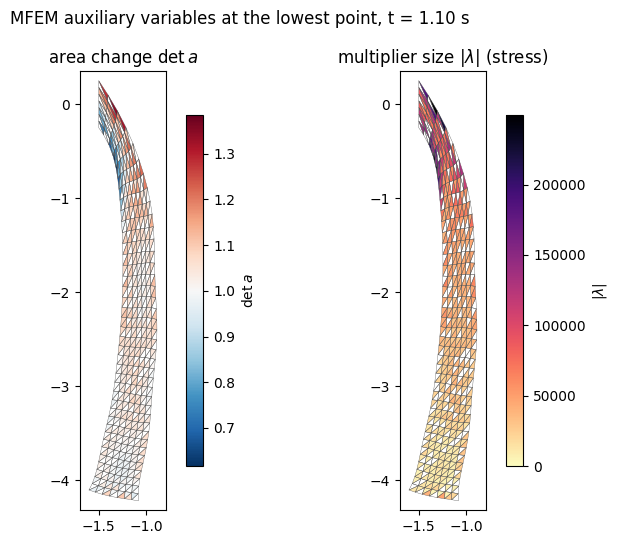

In [14]:
s_low = int(np.argmin([x[tip, 1] for x in runs["MFEM"]["frames"]]))   # step of the lowest tip
a_low, ll_low = runs["MFEM"]["a"][s_low], runs["MFEM"]["ll"][s_low]
det_field = np.full(len(T), np.nan)
det_field[cub_idx] = a_low[:, 0] * a_low[:, 1] - a_low[:, 2] ** 2
stress_field = np.full(len(T), np.nan)
stress_field[cub_idx] = np.linalg.norm(ll_low, axis=1)
det_range = np.nanmax(np.abs(det_field - 1))
print(f"t = {times[s_low]:.2f} s: det a in [{np.nanmin(det_field):.3f}, {np.nanmax(det_field):.3f}], "
      f"|lambda| up to {np.nanmax(stress_field):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(8, 5.5))
utils.plot_scalar_field(axes[0], runs["MFEM"]["frames"][s_low], T, det_field, title=r"area change $\det a$",
                        cmap="RdBu_r", vmin=1 - det_range, vmax=1 + det_range, label=r"$\det a$")
utils.plot_scalar_field(axes[1], runs["MFEM"]["frames"][s_low], T, stress_field,
                        title=r"multiplier size $|\lambda|$ (stress)", cmap="magma_r", vmin=0, label=r"$|\lambda|$")
fig.suptitle(f"MFEM auxiliary variables at the lowest point, t = {times[s_low]:.2f} s")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "stretch_stress.png"),
                              copy_to=os.path.join(MEDIA_DIR, "024_stretch_stress.png"))
plt.show()

## Regularization study: convergence vs $\rho_\text{aug}$

We stress the SQP with one large step from rest ($h$ = 0.5 s and 1 s) and count its iterations for each
augmentation weight; reaching `MAX_ITER_HARD` means it stalled. At $h$ = 0.5 s every weight up to $10^4$
converges in the same 13 iterations, $10^5$ needs 38 and $10^6$ stalls: a large penalty dominates the
condensed system and ruins its conditioning. At $h$ = 1 s the SQP stalls for every weight ($10^5$ stops just
short, at 58), so here augmentation does not rescue a hard step; it can only slow down an easy one.

h = 0.5 s: SQP iterations per rho_aug 0: 13, 1: 13, 10: 13, 100: 13, 1000: 13, 10000: 13, 100000: 38, 1e+06: 60*


h = 1 s: SQP iterations per rho_aug 0: 60*, 1: 60*, 10: 60*, 100: 60*, 1000: 60*, 10000: 60*, 100000: 58, 1e+06: 60*
(* = hit the cap: stalled)


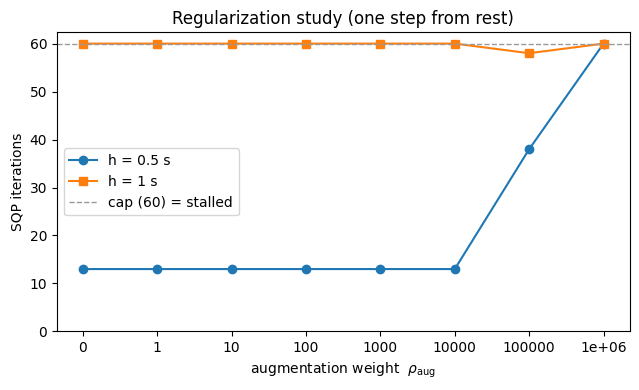

In [15]:
iters_rho = {}
for h_hard in H_HARD:
    iters_rho[h_hard] = []
    for rho_aug in RHO_SWEEP:
        energy_func, gradient_func, hessian_func = mfem_system(u_rest, u_rest, h_hard, mu, lam, rho_aug)
        p, n_iter = solve_mfem(np.vstack([u_rest, a_rest, ll_rest]), energy_func, gradient_func, hessian_func,
                               MAX_ITER_HARD)
        iters_rho[h_hard].append(n_iter)
    print(f"h = {h_hard:g} s: SQP iterations per rho_aug " + ", ".join(
        f"{r:g}: {k}{'*' if k >= MAX_ITER_HARD else ''}" for r, k in zip(RHO_SWEEP, iters_rho[h_hard])))
print("(* = hit the cap: stalled)")

fig, ax = plt.subplots(figsize=(6.5, 4))
for k, h_hard in enumerate(H_HARD):
    ax.plot(range(len(RHO_SWEEP)), iters_rho[h_hard], "os"[k % 2] + "-", color=f"C{k}", label=f"h = {h_hard:g} s")
ax.axhline(MAX_ITER_HARD, ls="--", c="0.6", lw=1, label=f"cap ({MAX_ITER_HARD}) = stalled")
ax.set_xticks(range(len(RHO_SWEEP)), [f"{r:g}" for r in RHO_SWEEP])
ax.set_xlabel(r"augmentation weight  $\rho_{\mathrm{aug}}$")
ax.set_ylabel("SQP iterations")
ax.set_title("Regularization study (one step from rest)")
ax.set_ylim(bottom=0); ax.legend(); fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "rho_study.png"),
                              copy_to=os.path.join(MEDIA_DIR, "024_rho_study.png"))
plt.show()

## Iterations vs stiffness

One very large step from rest ($h$ = `H_SWEEP`, nearly a static solve) for materials from soft to very
stiff: Newton iterations on FEM vs SQP iterations on MFEM, both capped at `MAX_ITER_SWEEP`. Both use the same
subspace and cubature, so only the formulation differs. On soft materials ($10^4$, $10^5$) MFEM hits the cap
while Newton converges in 15-20 iterations; as the material stiffens Newton slows down (30 at $10^6$) while
MFEM speeds up (20 at $10^6$, 5 against 11 at $10^7$), and on very stiff materials both need 3-4.

YM = 1e+04:  FEM Newton 15 iterations,  MFEM SQP 40 iterations


YM = 1e+05:  FEM Newton 20 iterations,  MFEM SQP 40 iterations


YM = 1e+06:  FEM Newton 30 iterations,  MFEM SQP 20 iterations
YM = 1e+07:  FEM Newton 11 iterations,  MFEM SQP  5 iterations
YM = 1e+08:  FEM Newton  4 iterations,  MFEM SQP  3 iterations
YM = 1e+09:  FEM Newton  3 iterations,  MFEM SQP  3 iterations


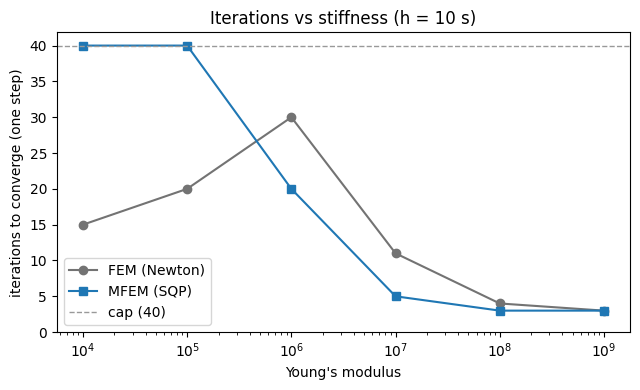

In [16]:
fem_iters, mfem_iters = [], []
for ym in YM_SWEEP:
    mu_s, lam_s = [np.full((N_CUBATURE, 1), v) for v in simkit.ympr_to_lame(ym, PR)]
    energy_func, gradient_func, hessian_func = fem_system(u_rest, u_rest, H_SWEEP, mu_s, lam_s)
    _, info = simkit.solvers.newton_solver(u_rest, energy_func, gradient_func, hessian_func, tolerance=TOL,
                                           max_iter=MAX_ITER_SWEEP, do_line_search=True, return_info=True)
    fem_iters.append(info["iters"] + 1)
    energy_func, gradient_func, hessian_func = mfem_system(u_rest, u_rest, H_SWEEP, mu_s, lam_s, RHO_AUG)
    _, n_iter = solve_mfem(np.vstack([u_rest, a_rest, ll_rest]), energy_func, gradient_func, hessian_func,
                           MAX_ITER_SWEEP)
    mfem_iters.append(n_iter)
    print(f"YM = {ym:.0e}:  FEM Newton {fem_iters[-1]:2d} iterations,  MFEM SQP {mfem_iters[-1]:2d} iterations")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogx(YM_SWEEP, fem_iters, "o-", color="0.45", label="FEM (Newton)")
ax.semilogx(YM_SWEEP, mfem_iters, "s-", color="C0", label="MFEM (SQP)")
ax.axhline(MAX_ITER_SWEEP, ls="--", c="0.6", lw=1, label=f"cap ({MAX_ITER_SWEEP})")
ax.set_xlabel("Young's modulus")
ax.set_ylabel("iterations to converge (one step)")
ax.set_title(f"Iterations vs stiffness (h = {H_SWEEP:g} s)")
ax.set_ylim(bottom=0); ax.legend(); fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "stiffness_iterations.png"),
                              copy_to=os.path.join(MEDIA_DIR, "024_stiffness_iterations.png"))
plt.show()

## Cost of one iteration

Iteration counts are half the story, so we time one full iteration of each solver (assembly, solve, line
search) at the rest state of the drop, best of `TIMING_REPS`. An MFEM iteration costs several Newton
iterations here: on top of the same $60 \times 60$ solve it differentiates a polar decomposition per
cubature triangle ($\partial S/\partial u$) and assembles 400 blocks. On this small mesh, in Python, FEM
therefore stays faster in wall-clock time even where MFEM saves iterations.

In [17]:
energy_func, gradient_func, hessian_func = fem_system(u_rest, u_rest, DT, mu, lam)
t_fem = utils.best_time(lambda: simkit.solvers.newton_solver(u_rest, energy_func, gradient_func, hessian_func,
                                                             max_iter=1), rep=TIMING_REPS)
energy_func, gradient_func, hessian_func = mfem_system(u_rest, u_rest, DT, mu, lam, RHO_AUG)
t_mfem = utils.best_time(lambda: solve_mfem(np.vstack([u_rest, a_rest, ll_rest]), energy_func, gradient_func,
                                            hessian_func, 1), rep=TIMING_REPS)
print(f"one FEM Newton iteration: {1e3 * t_fem:6.1f} ms   ({n_u} x {n_u} solve)")
print(f"one MFEM SQP iteration:   {1e3 * t_mfem:6.1f} ms   ({n_u} x {n_u} condensed solve + {n_a} stretch DOFs)")

one FEM Newton iteration:    1.4 ms   (60 x 60 solve)
one MFEM SQP iteration:      7.2 ms   (60 x 60 condensed solve + 1200 stretch DOFs)


## Takeaways

* **Mixed FEM** moves the elastic energy onto per-element stretch variables: its Hessian is block-diagonal, the positions only see inertia, pins and the constraint, and `sqp_mfem` condenses everything into one $n_u \times n_u$ solve per iteration.
* Subspace FEM and MFEM give the same motion here (within $2\cdot10^{-4}$). MFEM needs more iterations on soft materials, where its Gauss-Newton $H_u$ converges linearly under large stresses, and fewer than Newton on stiff ones.
* Augmentation weights $\rho_\text{aug}$ up to $10^4$ cost nothing in this study; larger ones slow the solve until it stalls, and no weight rescued the hardest step.
* simkit's `examples/interactive_demos/012_interactive_mixed_fem.py` is a mouse-draggable version of this solver, and `tests/test_mfem_blocks.py` holds the block checks.